Exhaustive search for RU selection
----------------------------
An example of exhaustive search/flickering to perform RU selection.

In [57]:
import yaml
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from plotter import plotter
from utils import calculate_psd_per_symbol
from wireless_channel.waveforms import Waveform
from sub_THz_stripe.radiostripe.radiostripe import RadioStripe
from sub_THz_stripe.radio_unit.radio_unit import RadioUnit
from wireless_channel.subTHz_channel import Channel
from sub_THz_stripe.central_unit.central_unit import CentralUnit

In [ ]:
# Read out the config file.
config_file = "examples/flickering/config.yml"
with open(config_file, "r", encoding="utf8") as file:
    config = yaml.safe_load(file)

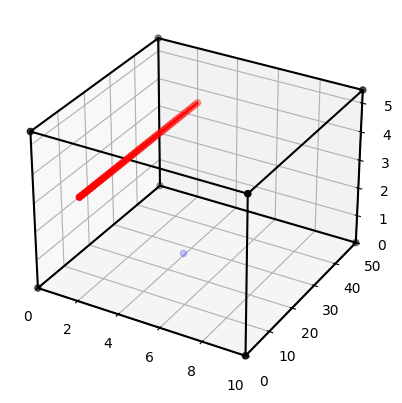

In [59]:
# Plot the room with the strip in it.
plotter.plot_room(config)

In [60]:
# Construct the waveform class based on the loaded configuration.
waveform_config = config["waveform_config"]
freq_band_config = config["sub_thz"]
wf = Waveform.from_config(waveform_config, freq_band_config)

In [ ]:
# Build all the RadioStripe objects based on the configuration.
stripes: list[RadioStripe] = []
component_config = config["component_config"]
stripe_cfg = config["radio_stripes"][0]
for stripe_cfg in config["radio_stripes"]:
    stripes.append(RadioStripe.from_config_locations(stripe_cfg, component_config, wf))

In [62]:
# Generate an CP-OFDM waveform in the time domain.
bits = wf.generate_bits()
qam = wf.qam_modulate()
ofdm_time = wf.ofdm_modulate()  # shape: nr_ofdm_symb x (fftsize + cp length)

In [ ]:
# The UE has the same hardware as a central unit.
ue = CentralUnit()  # todo are these configs loadable?
ofdm_time_after_ue = ue.run(ofdm_time)  # shape: nr_ofdm_symbols x (fft_size + cp length)

# A single radio unit is used to represent the transmit stage of the ue. The UE position does not influence the
# transmission so we can set it arbitrarily.
ue_ru = RadioUnit(x=0, y=0, z=0, wf=wf)
# Transmit the data towards the stripe. We only perform this task once. Every UE in the room will transmit the same
# signal towards the stripe. Only its position and hence the channel will change.
shifts = [0, 0, 0, 0]
iq_data_tx, imdata = ue_ru.transmit(ofdm_time_after_ue, shifts)

In [ ]:
# Loop over all the UE positions and perform an exhaustive search.
ue_data = []
for ue_pos in config["ue_positions"]:
    # Construct the wireless channel for this UE.
    channel = Channel.from_sionna(ue_pos)

    # Transmit the data over the channel and get the data at all the radio units.
    iq_data_rx = channel.transmit_ul(iq_data_tx, wf)

    # Now receive this data on all the stripes.
    stripe_data = []
    for stripe, data in zip(stripes, iq_data_rx):
        phase_shifts = [0, 0, 0, 0]
        iq_out, imdata = stripe.receive_all(data, phase_shifts, delay=True)

        stripe_data.append(iq_out)
    
    ue_data.append(stripe_data)

In [ ]:
# TODO: Process the data.